# Training vs Generated Data Analysis

Compares aggregate statistics, distributions and temporal structure between:
- **Reference**: the first `TRAINING_DATASET_SIZE` CSVs from the training directory (sorted)
- **Generated**: all CSVs produced by the reverse-diffusion model

Both datasets are either log-prices or log-returns.
Reference paths may be full-length stock histories; generated paths are fixed-length windows.

In [1]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
REF_DIRECTORY         = "../data/replication_returns_other"          # training data folder
GEN_DIRECTORY         = "../data/generated/final/replication/ODE_NO_NO_REPL_RET_OTHER_UNCO_ep-1000_sde-vp_noise-linear_20260527_131801_N2000_seq2048_stride400_seed50"
SEED                  = 50  
TRAINING_SEED         = 50    # must match config["train"]["seed"] used during training
                               
TRAINING_DATASET_SIZE = None
VAL_SPLIT_RATIO = 0.05 # set to None to use all available (post-val) windows
SEQ_LEN               = 2048  # window length used during training (--seq_len)
STRIDE                = 400   # stride used during training (--stride)
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import acf as sm_acf

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print(f"REF_DIRECTORY         : {REF_DIRECTORY}")
print(f"GEN_DIRECTORY         : {GEN_DIRECTORY}")
print(f"SEED                  : {SEED}")
print(f"TRAINING_DATASET_SIZE : {TRAINING_DATASET_SIZE}")
print(f"SEQ_LEN               : {SEQ_LEN}")
print(f"STRIDE                : {STRIDE}")

REF_DIRECTORY         : ../data/replication_returns_other
GEN_DIRECTORY         : ../data/generated/final/replication/ODE_NO_NO_REPL_RET_OTHER_UNCO_ep-1000_sde-vp_noise-linear_20260527_131801_N2000_seq2048_stride400_seed50
SEED                  : 50
TRAINING_DATASET_SIZE : None
SEQ_LEN               : 2048
STRIDE                : 400


## 1. Load data

In [3]:
# ── Reference data ────────────────────────────────────────────────────────────
# Mirrors csdi_train_modified.py exactly:
#   1. Load ALL sorted CSVs — no file cap
#   2. Extract sliding windows with same SEQ_LEN / STRIDE / drop_incomplete=True
#   3. Replicate torch.randperm(seed) + val split + train_subset_size
import torch

ref_csv_files = sorted(Path(REF_DIRECTORY).glob("*.csv"))
if len(ref_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {REF_DIRECTORY}")

all_windows: list[np.ndarray] = []
n_skipped_short = 0
for fp in ref_csv_files:
    series = pd.read_csv(fp)["log_adj_close"].values.astype(np.float64)
    T = len(series)
    max_start = T - SEQ_LEN
    if max_start < 0:   # shorter than SEQ_LEN — skip (drop_incomplete=True)
        n_skipped_short += 1
        continue
    for s in range(0, max_start + 1, STRIDE):
        all_windows.append(series[s : s + SEQ_LEN])

if n_skipped_short:
    print(f"[WARNING] {n_skipped_short} file(s) shorter than SEQ_LEN={SEQ_LEN} were skipped.")
if len(all_windows) == 0:
    raise RuntimeError("No windows could be extracted. Check SEQ_LEN / STRIDE / REF_DIRECTORY.")

print(f"Total windows in full dataset : {len(all_windows)} "
      f"(from {len(ref_csv_files) - n_skipped_short} usable file(s), "
      f"SEQ_LEN={SEQ_LEN}, STRIDE={STRIDE})")

# ── Replicate training subset selection with torch RNG ────────────────────────
torch_rng  = torch.Generator().manual_seed(TRAINING_SEED)
all_indices = torch.randperm(len(all_windows), generator=torch_rng).tolist()

# Carve out val split first (mirrors val_split_ratio logic in training script)
if VAL_SPLIT_RATIO is not None:
    val_size   = max(1, int(len(all_windows) * VAL_SPLIT_RATIO))
    train_pool = all_indices[val_size:]
    print(f"Val split : {val_size} windows held out (VAL_SPLIT_RATIO={VAL_SPLIT_RATIO})")
else:
    train_pool = all_indices

# Then take TRAINING_DATASET_SIZE from the remaining pool
if TRAINING_DATASET_SIZE is not None and TRAINING_DATASET_SIZE < len(train_pool):
    train_indices = train_pool[:TRAINING_DATASET_SIZE]
    print(f"Reference : {len(train_indices)} windows "
          f"(TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} of {len(train_pool)} in pool)")
else:
    train_indices = train_pool
    if TRAINING_DATASET_SIZE is not None:
        print(f"[WARNING] TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} >= pool size "
              f"({len(train_pool)}); using all pool windows.")
    print(f"Reference : {len(train_indices)} windows (full training pool)")

ref_paths = [all_windows[i] for i in train_indices]

assert all(len(w) == SEQ_LEN for w in ref_paths), "Window length mismatch — check SEQ_LEN"
print(f"  All window lengths = {SEQ_LEN}  ✓")

Total windows in full dataset : 5568 (from 210 usable file(s), SEQ_LEN=2048, STRIDE=400)
Val split : 278 windows held out (VAL_SPLIT_RATIO=0.05)
Reference : 5290 windows (full training pool)
  All window lengths = 2048  ✓


In [4]:
# ── Generated data ────────────────────────────────────────────────────────────
# Load ALL CSV files in GEN_DIRECTORY (no size cap).
# Two formats are supported:
#   (a) Per-sample CSVs  — columns: date, log_adj_close  (one file per path)
#   (b) Wide-format CSV  — columns: sample_idx, start_date, end_date, step_000, step_001, ...
#       (produced by generate_samples.py as "generated_samples.csv")
gen_csv_files = sorted(Path(GEN_DIRECTORY).glob("*.csv"))

if len(gen_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {GEN_DIRECTORY}")

gen_paths: list[np.ndarray] = []
skipped = 0
for fp in gen_csv_files:
    df = pd.read_csv(fp)
    if "log_adj_close" in df.columns:
        # Format (a): individual per-sample CSV
        gen_paths.append(df["log_adj_close"].values.astype(np.float64))
    else:
        # Format (b): wide-format — each row is one sample path
        step_cols = sorted(
            [c for c in df.columns if c.startswith("step_")],
            key=lambda c: int(c.split("_")[1])
        )
        print(step_cols[999:], f"\n first column: {step_cols[0]}, last column: {step_cols[-1]}")
        if step_cols:
            print(df.head())
            for _, row in df.iterrows():
                gen_paths.append(row[step_cols].values.astype(np.float64))
        else:
            skipped += 1

if skipped:
    print(f"[WARNING] Skipped {skipped} file(s) with unrecognised column layout.")
if len(gen_paths) == 0:
    raise RuntimeError("No valid generated paths could be loaded from GEN_DIRECTORY.")

gen_lens = [len(p) for p in gen_paths]
# print(f"Generated: {len(gen_paths)} paths loaded  ({len(gen_csv_files)} CSV file(s) read)")
# print(f"  Path lengths — min={min(gen_lens)}  max={max(gen_lens)}  "
#       f"median={int(np.median(gen_lens))}")

# print(gen_paths[0][:5], "\n", gen_paths[0][-5:])
# print(gen_paths[-1][:5], "\n", gen_paths[-1][-5:])

['step_999', 'step_1000', 'step_1001', 'step_1002', 'step_1003', 'step_1004', 'step_1005', 'step_1006', 'step_1007', 'step_1008', 'step_1009', 'step_1010', 'step_1011', 'step_1012', 'step_1013', 'step_1014', 'step_1015', 'step_1016', 'step_1017', 'step_1018', 'step_1019', 'step_1020', 'step_1021', 'step_1022', 'step_1023', 'step_1024', 'step_1025', 'step_1026', 'step_1027', 'step_1028', 'step_1029', 'step_1030', 'step_1031', 'step_1032', 'step_1033', 'step_1034', 'step_1035', 'step_1036', 'step_1037', 'step_1038', 'step_1039', 'step_1040', 'step_1041', 'step_1042', 'step_1043', 'step_1044', 'step_1045', 'step_1046', 'step_1047', 'step_1048', 'step_1049', 'step_1050', 'step_1051', 'step_1052', 'step_1053', 'step_1054', 'step_1055', 'step_1056', 'step_1057', 'step_1058', 'step_1059', 'step_1060', 'step_1061', 'step_1062', 'step_1063', 'step_1064', 'step_1065', 'step_1066', 'step_1067', 'step_1068', 'step_1069', 'step_1070', 'step_1071', 'step_1072', 'step_1073', 'step_1074', 'step_1075',

## 2. Aggregate statistics

In [5]:
def compute_stats(paths: list[np.ndarray], label: str) -> dict:
    flat = np.concatenate(paths)
    incs = np.concatenate([np.diff(p) for p in paths if len(p) > 1])
    return {
        "label"            : label,
        "n_paths"          : len(paths),
        "n_values"         : len(flat),
        "mean"             : flat.mean(),
        "std"              : flat.std(),
        "min"              : flat.min(),
        "q01"              : np.quantile(flat, 0.01),
        "q05"              : np.quantile(flat, 0.05),
        "q25"              : np.quantile(flat, 0.25),
        "q50"              : np.quantile(flat, 0.50),
        "q75"              : np.quantile(flat, 0.75),
        "q95"              : np.quantile(flat, 0.95),
        "q99"              : np.quantile(flat, 0.99),
        "max"              : flat.max(),
        "skewness"         : scipy_stats.skew(flat),
        "excess_kurtosis"  : scipy_stats.kurtosis(flat, fisher=True),
        "inc_mean"         : incs.mean(),
        "inc_std"          : incs.std(),
        "inc_min"          : incs.min(),
        "inc_q01"          : np.quantile(incs, 0.01),
        "inc_q99"          : np.quantile(incs, 0.99),
        "inc_max"          : incs.max(),
        "inc_skewness"     : scipy_stats.skew(incs),
        "inc_excess_kurt"  : scipy_stats.kurtosis(incs, fisher=True),
    }

ref_stats = compute_stats(ref_paths, "Reference (training)")
gen_stats = compute_stats(gen_paths, "Generated")

# ── Levels table ──────────────────────────────────────────────────────────────
level_keys = ["n_paths", "n_values", "mean", "std", "min", "q01", "q05",
              "q25", "q50", "q75", "q95", "q99", "max", "skewness", "excess_kurtosis"]
df_levels = pd.DataFrame(
    {k: {"Reference": ref_stats[k], "Generated": gen_stats[k]} for k in level_keys}
).T.round(4)

print("=" * 60)
print("  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)")
print("=" * 60)
display(df_levels.style.format("{:.4f}"))

  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)


,Reference,Generated
n_paths,5290.0000,512.0000
n_values,10833920.0000,1048576.0000
mean,0.0005,0.0023
std,0.0208,0.0446
min,-0.9363,-3.7898
q01,-0.0562,-0.0739
q05,-0.0291,-0.0438
q25,-0.0086,-0.0161
q50,0.0000,0.0014
q75,0.0095,0.0190


In [6]:
for paths, label in [(ref_paths, "Reference"), (gen_paths, "GenWerated")]:
    flat = np.concatenate(paths)
    zero_pct = 100.0 * np.mean(flat == 0.0)
    print(f"{label}: {zero_pct:.4f}% absolute zeros ({(flat == 0.0).sum()} / {len(flat)})")


Reference: 7.1735% absolute zeros (777169 / 10833920)
GenWerated: 0.0000% absolute zeros (0 / 1048576)


In [7]:
# ── Increments table ──────────────────────────────────────────────────────────
inc_keys = ["inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99",
            "inc_max", "inc_skewness", "inc_excess_kurt"]
rename = {
    "inc_mean": "mean", "inc_std": "std", "inc_min": "min",
    "inc_q01": "q01", "inc_q99": "q99", "inc_max": "max",
    "inc_skewness": "skewness", "inc_excess_kurt": "excess_kurtosis",
}
df_incs = pd.DataFrame(
    {rename[k]: {"Reference": ref_stats[k], "Generated": gen_stats[k]}
     for k in inc_keys}
).T.round(6)

print("=" * 60)
print("  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics")
print("=" * 60)
display(df_incs.style.format("{:.4f}"))

  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics


,Reference,Generated
mean,0.0000,0.0000
std,0.0296,0.0594
min,-1.3863,-5.2647
q01,-0.0805,-0.1147
q99,0.0820,0.1159
max,1.0291,5.1979
skewness,0.2566,-0.0777
excess_kurtosis,26.8585,307.8192


## 2b. Aggregate statistics — full stock series vs generated

In [8]:
# Load full stock series from REF_DIRECTORY (one per stock, no windowing)
ref_full_paths = []
for fp in sorted(Path(REF_DIRECTORY).glob("*.csv")):
    series = pd.read_csv(fp)["log_adj_close"].values.astype(np.float64)
    ref_full_paths.append(series)

print(f"Full stock series loaded : {len(ref_full_paths)}")
print(f"Lengths — min={min(len(s) for s in ref_full_paths)}  "
      f"max={max(len(s) for s in ref_full_paths)}  "
      f"mean={np.mean([len(s) for s in ref_full_paths]):.0f}")

ref_full_stats = compute_stats(ref_full_paths, "Reference (full series)")

# ── Levels table ──────────────────────────────────────────────────────────────
level_keys = ["n_paths", "n_values", "mean", "std", "min", "q01", "q05",
              "q25", "q50", "q75", "q95", "q99", "max", "skewness", "excess_kurtosis"]
df_levels_full = pd.DataFrame(
    {k: {"Reference (full)": ref_full_stats[k], "Generated": gen_stats[k]} for k in level_keys}
).T.round(4)

print("\n" + "=" * 60)
print("  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)")
print("=" * 60)
display(df_levels_full.style.format("{:.4f}"))

# ── Increments table ──────────────────────────────────────────────────────────
inc_keys = ["inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99",
            "inc_max", "inc_skewness", "inc_excess_kurt"]
rename = {
    "inc_mean": "mean", "inc_std": "std", "inc_min": "min",
    "inc_q01": "q01", "inc_q99": "q99", "inc_max": "max",
    "inc_skewness": "skewness", "inc_excess_kurt": "excess_kurtosis",
}
df_incs_full = pd.DataFrame(
    {rename[k]: {"Reference (full)": ref_full_stats[k], "Generated": gen_stats[k]}
     for k in inc_keys}
).T.round(6)

print("\n" + "=" * 60)
print("  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics")
print("=" * 60)
display(df_incs_full.style.format("{:.4f}"))

Full stock series loaded : 210
Lengths — min=10083  max=16175  mean=12493

  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)


,Reference (full),Generated
n_paths,210.0000,512.0000
n_values,2623490.0000,1048576.0000
mean,0.0005,0.0023
std,0.0209,0.0446
min,-0.9363,-3.7898
q01,-0.0564,-0.0739
q05,-0.0292,-0.0438
q25,-0.0086,-0.0161
q50,0.0000,0.0014
q75,0.0095,0.0190



  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics


,Reference (full),Generated
mean,-0.0000,0.0000
std,0.0297,0.0594
min,-1.3863,-5.2647
q01,-0.0805,-0.1147
q99,0.0820,0.1159
max,1.0291,5.1979
skewness,0.2227,-0.0777
excess_kurtosis,29.4105,307.8192


## Per-window statistics

Per-window statistics — summary (mean ± std across windows)


,Reference mean,Reference std,Generated mean,Generated std
mean,0.0005,0.0004,0.0023,0.0143
std,0.0196,0.0069,0.0311,0.0287
skewness,-0.3403,1.3745,-0.0538,0.4008
excess_kurt,14.0761,36.3552,2.7475,4.8765
zero_ratio,0.0717,0.0936,0.0000,0.0000
inc_std,0.0279,0.0100,0.0438,0.0401
inc_skewness,0.2385,0.4993,0.0451,0.1184
inc_excess_kurt,11.2795,23.0052,2.0108,3.4452


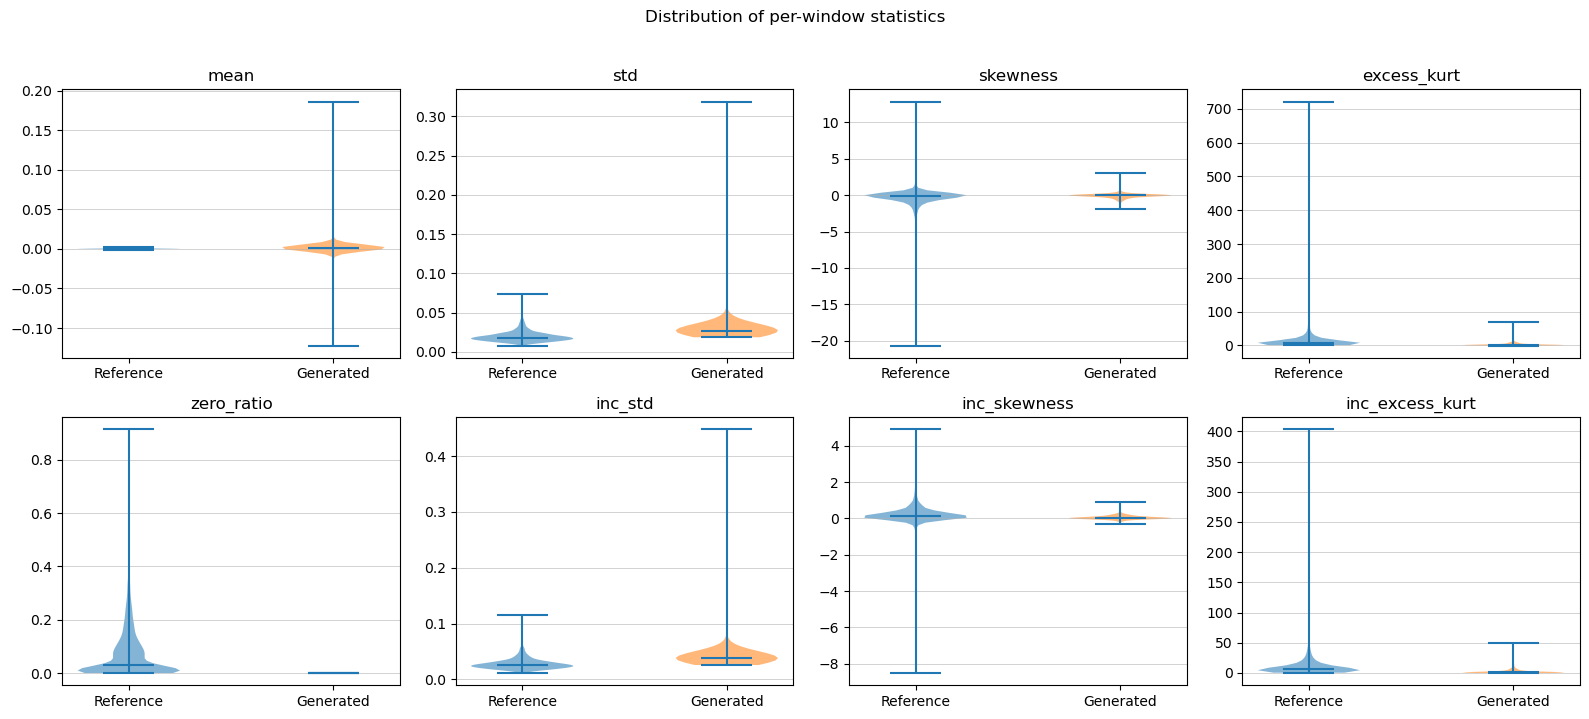

In [9]:
def per_window_stats(paths: list[np.ndarray]) -> pd.DataFrame:
    rows = []
    for p in paths:
        incs = np.diff(p)
        rows.append({
            "mean"         : float(p.mean()),
            "std"          : float(p.std()),
            "skewness"     : float(scipy_stats.skew(p)),
            "excess_kurt"  : float(scipy_stats.kurtosis(p, fisher=True)),
            "zero_ratio"   : float(np.mean(p == 0.0)),
            "inc_std"      : float(incs.std()),
            "inc_skewness" : float(scipy_stats.skew(incs)),
            "inc_excess_kurt": float(scipy_stats.kurtosis(incs, fisher=True)),
        })
    return pd.DataFrame(rows)

ref_pw = per_window_stats(ref_paths)
gen_pw = per_window_stats(gen_paths)

# ── Summary table: mean ± std of each per-window stat ────────────────────────
summary = pd.DataFrame({
    "Reference  mean": ref_pw.mean(),
    "Reference  std" : ref_pw.std(),
    "Generated  mean": gen_pw.mean(),
    "Generated  std" : gen_pw.std(),
}).round(5)
print("Per-window statistics — summary (mean ± std across windows)")
display(summary.style.format("{:.4f}"))

# ── Violin plots ──────────────────────────────────────────────────────────────
metrics = list(ref_pw.columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, metric in zip(axes.flat, metrics):
    data  = [ref_pw[metric].values, gen_pw[metric].values]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=True, showextrema=True)
    parts["bodies"][0].set_facecolor("tab:blue");   parts["bodies"][0].set_alpha(0.55)
    parts["bodies"][1].set_facecolor("tab:orange"); parts["bodies"][1].set_alpha(0.55)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Reference", "Generated"])
    ax.set_title(metric)
    ax.grid(axis="y", linewidth=0.4)

plt.suptitle("Distribution of per-window statistics", y=1.02)
plt.tight_layout()
plt.show()


## 3. Level distribution: histogram, QQ plot, ECDF

In [10]:
gen_checkpoint_name = os.path.basename(GEN_DIRECTORY.rstrip('/'))
ref_checkpoint_name = os.path.basename(REF_DIRECTORY.rstrip('/'))

Levels KS statistic = 0.1421  |  p-value = 0.0000e+00
Wasserstein-1 distance (levels) = 0.0107


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30292\1027832513.py:56: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30292\1027832513.py:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"../images/final/replication/comparison/level_distributions_comparison_{gen_checkpoint_name}.png", dpi=300)
c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


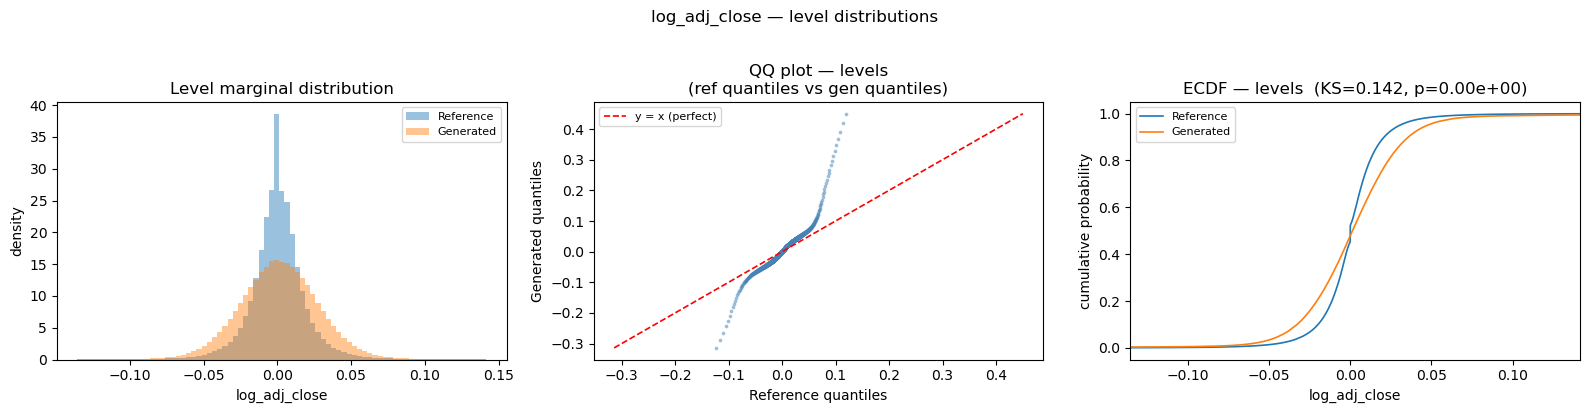

In [11]:
ref_flat = np.concatenate(ref_paths)
gen_flat = np.concatenate(gen_paths)

ks_stat_lev, ks_p_lev = scipy_stats.ks_2samp(ref_flat, gen_flat)
print(f"Levels KS statistic = {ks_stat_lev:.4f}  |  p-value = {ks_p_lev:.4e}")

w1_stat = scipy_stats.wasserstein_distance(ref_flat, gen_flat)
print(f"Wasserstein-1 distance (levels) = {w1_stat:.4f}")


combined = np.concatenate([ref_flat, gen_flat])
lo, hi   = np.quantile(combined, [0.001, 0.999])
bins     = np.linspace(lo, hi, 80)
xs       = np.linspace(lo, hi, 400)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_flat, bins=bins, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_flat, bins=bins, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Level marginal distribution")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot (ref quantiles vs gen quantiles)
ax = axes[1]
n_q  = min(len(ref_flat), len(gen_flat), 5_000)
probs = np.linspace(0.001, 0.999, n_q)
q_ref = np.quantile(ref_flat, probs)
q_gen = np.quantile(gen_flat, probs)
ax.scatter(q_ref, q_gen, s=3, alpha=0.4, color="steelblue")
lims = [min(q_ref.min(), q_gen.min()), max(q_ref.max(), q_gen.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — levels\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_flat, "Reference", "tab:blue"),
    (gen_flat, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF — levels  (KS={ks_stat_lev:.3f}, p={ks_p_lev:.2e})")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("log_adj_close — level distributions", y=1.02)
plt.tight_layout()
plt.savefig(f"../images/final/replication/comparison/level_distributions_comparison_{gen_checkpoint_name}.png", dpi=300)
plt.show()

## 4. Increment distribution: histogram, QQ plot, ECDF

Increments KS statistic = 0.1251  |  p-value = 0.0000e+00
Wasserstein-1 distance (levels) = 0.0145


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30292\488449731.py:54: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30292\488449731.py:55: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"../images/final/replication/comparison/increments_distributions_comparison_{gen_checkpoint_name}.png", dpi=300)


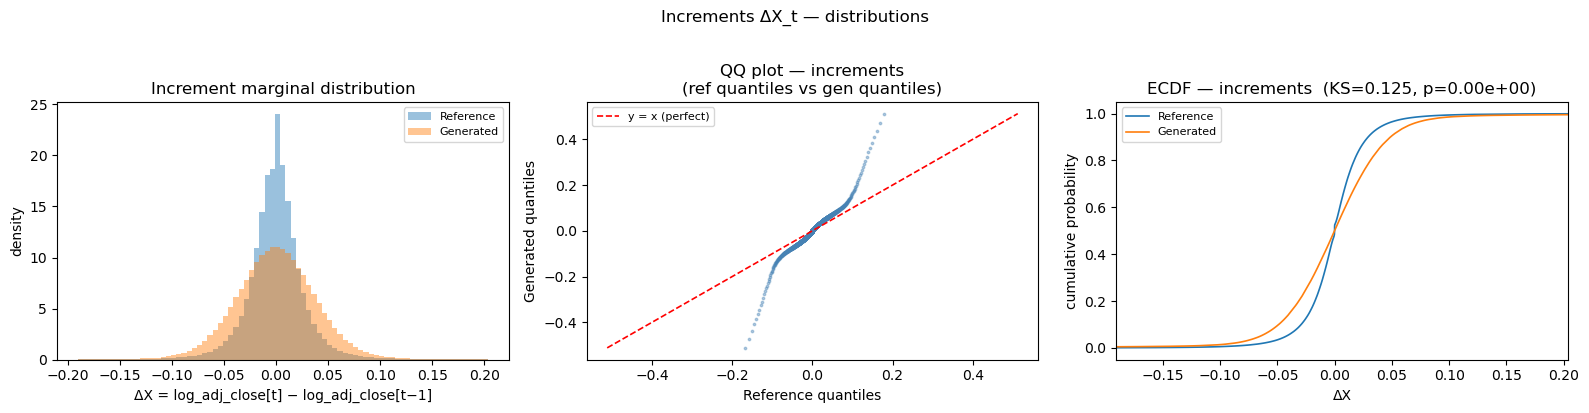

In [12]:
ref_incs = np.concatenate([np.diff(p) for p in ref_paths if len(p) > 1])
gen_incs = np.concatenate([np.diff(p) for p in gen_paths if len(p) > 1])

ks_stat_inc, ks_p_inc = scipy_stats.ks_2samp(ref_incs, gen_incs)
print(f"Increments KS statistic = {ks_stat_inc:.4f}  |  p-value = {ks_p_inc:.4e}")

w1_stat = scipy_stats.wasserstein_distance(ref_incs, gen_incs)
print(f"Wasserstein-1 distance (levels) = {w1_stat:.4f}")

combined_inc = np.concatenate([ref_incs, gen_incs])
lo_i, hi_i  = np.quantile(combined_inc, [0.001, 0.999])
bins_i      = np.linspace(lo_i, hi_i, 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_incs, bins=bins_i, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_incs, bins=bins_i, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Increment marginal distribution")
ax.set_xlabel("ΔX = log_adj_close[t] − log_adj_close[t−1]")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot
ax = axes[1]
n_q  = min(len(ref_incs), len(gen_incs), 5_000)
probs = np.linspace(0.001, 0.999, n_q)
q_ref_i = np.quantile(ref_incs, probs)
q_gen_i = np.quantile(gen_incs, probs)
ax.scatter(q_ref_i, q_gen_i, s=3, alpha=0.4, color="steelblue")
lims_i = [min(q_ref_i.min(), q_gen_i.min()), max(q_ref_i.max(), q_gen_i.max())]
ax.plot(lims_i, lims_i, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — increments\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_incs, "Reference", "tab:blue"),
    (gen_incs, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo_i, hi_i)
ax.set_title(f"ECDF — increments  (KS={ks_stat_inc:.3f}, p={ks_p_inc:.2e})")
ax.set_xlabel("ΔX")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("Increments ΔX_t — distributions", y=1.02)
plt.tight_layout()
plt.savefig(f"../images/final/replication/comparison/increments_distributions_comparison_{gen_checkpoint_name}.png", dpi=300)
plt.show()

## 5. Sample paths

Visual check: do the shapes, scale, and fan-out look alike?

Reference paths may be longer; if so, a random window of the generated-path length is
extracted (using `SEED`) for a fair apples-to-apples visual.

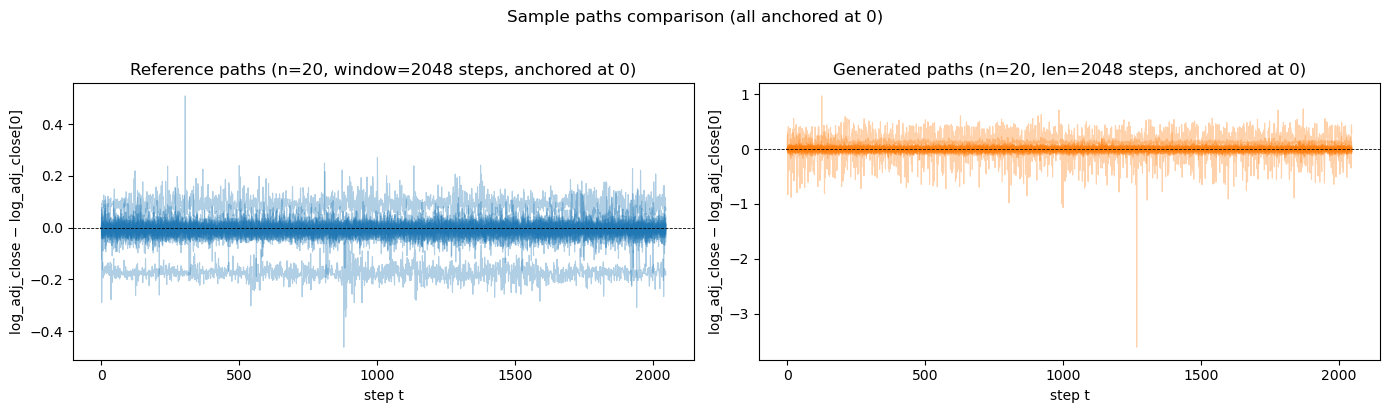

In [13]:
N_SHOW   = 20
GEN_LEN  = int(np.median(gen_lens))   # typical generated path length

# Sample random paths from each dataset
ref_idx = rng.choice(len(ref_paths), size=min(N_SHOW, len(ref_paths)), replace=False)
gen_idx = rng.choice(len(gen_paths), size=min(N_SHOW, len(gen_paths)), replace=False)

def extract_window(path: np.ndarray, window_len: int, rng: np.random.Generator) -> np.ndarray:
    """Extract a random window of `window_len` from `path`."""
    if len(path) <= window_len:
        return path
    start = rng.integers(0, len(path) - window_len + 1)
    return path[start : start + window_len]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

# Reference
ax = axes[0]
for i in ref_idx:
    p = extract_window(ref_paths[i], GEN_LEN, rng)
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:blue")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Reference paths (n={len(ref_idx)}, window={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

# Generated
ax = axes[1]
for i in gen_idx:
    p = gen_paths[i]
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:orange")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Generated paths (n={len(gen_idx)}, len={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

plt.suptitle("Sample paths comparison (all anchored at 0)", y=1.02)
plt.tight_layout()
plt.savefig
plt.savefig(f"../images/comparison/sample_paths_comparison_{gen_checkpoint_name}.png", dpi=300)
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30292\1385919306.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _tab20 = plt.cm.get_cmap("tab20", 20)


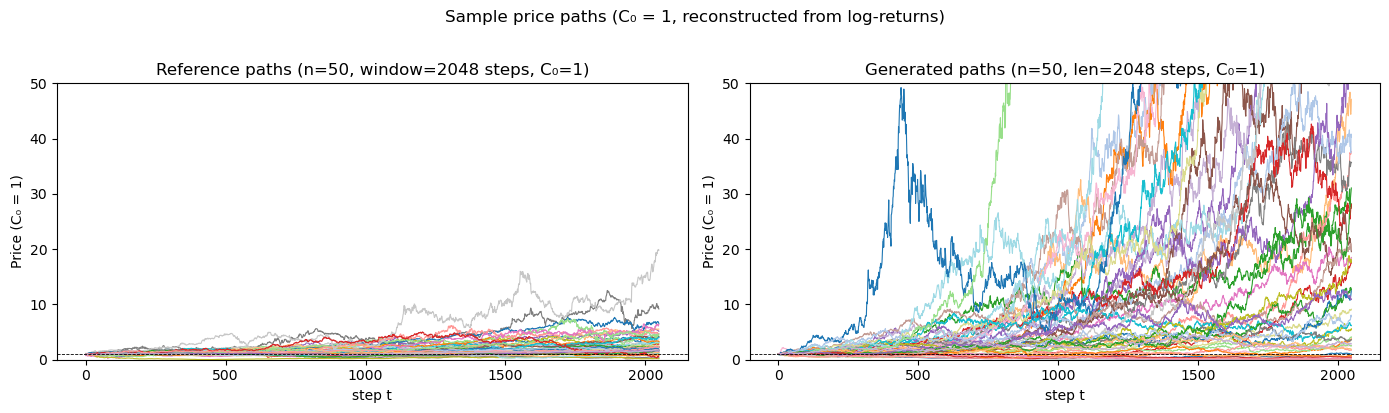

In [14]:

N_SHOW    = 50
PLOT_SEED = SEED
GEN_LEN   = int(np.median(gen_lens))

_rng = np.random.default_rng(PLOT_SEED)

ref_idx = _rng.choice(len(ref_paths), size=min(N_SHOW, len(ref_paths)), replace=False)
gen_idx = _rng.choice(len(gen_paths), size=min(N_SHOW, len(gen_paths)), replace=False)

def extract_window(path: np.ndarray, window_len: int, rng: np.random.Generator) -> np.ndarray:
    if len(path) <= window_len:
        return path
    start = rng.integers(0, len(path) - window_len + 1)
    return path[start : start + window_len]

def to_price_path(log_returns: np.ndarray) -> np.ndarray:
    """Reconstruct price path from log-returns, assuming C_0 = 1."""
    return np.exp(np.concatenate([[0.0], np.cumsum(log_returns)]))

n_ref = len(ref_idx)
n_gen = len(gen_idx)
_tab20 = plt.cm.get_cmap("tab20", 20)
colors = [_tab20(k) for k in range(20)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

# Reference
ax = axes[0]
for k, i in enumerate(ref_idx):
    p = extract_window(ref_paths[i], GEN_LEN, _rng)
    price = to_price_path(p)
    ax.plot(np.arange(len(price)), price, alpha=1.0, linewidth=0.8, color=colors[k % 20])
ax.axhline(1.0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Reference paths (n={n_ref}, window={GEN_LEN} steps, C₀=1)")
ax.set_xlabel("step t")
ax.set_ylim(0, 50)
ax.set_ylabel("Price (C₀ = 1)")

# Generated
ax = axes[1]
for k, i in enumerate(gen_idx):
    price = to_price_path(gen_paths[i])
    ax.plot(np.arange(len(price)), price, alpha=1.0, linewidth=0.8, color=colors[k % 20])
ax.axhline(1.0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Generated paths (n={n_gen}, len={GEN_LEN} steps, C₀=1)")
ax.set_xlabel("step t")
ax.set_ylim(0, 50)
ax.set_ylabel("Price (C₀ = 1)")

plt.suptitle("Sample price paths (C₀ = 1, reconstructed from log-returns)", y=1.02)
plt.tight_layout()
plt.savefig(f"../images/final/replication/comparison/sample_paths_price_{gen_checkpoint_name}.png", dpi=300)
plt.show()

# 8. Paper's FTS evaluations metrics
These metrics are written to work on **LOG-RETURN**.

In [15]:
sys.path.append(os.path.abspath(".."))

import replication.stylized_facts as sf
import numpy as np

In [16]:
# Reference: full stock series (not windows)
ref_full = {}
for csv_path in sorted(Path(REF_DIRECTORY).glob("*.csv")):
    df = pd.read_csv(csv_path)
    ref_full[csv_path.stem] = df["log_adj_close"].to_numpy(dtype=float)

ref_full_obj    = np.empty(len(ref_full), dtype=object)
ref_full_pooled = np.concatenate(list(ref_full.values()))
for i, r in enumerate(ref_full.values()):
    ref_full_obj[i] = r

# Generated: already 2048-pt independent samples — use as-is
# gen_paths_obj and gen_paths_arr unchanged


In [17]:
# Use sf.distribution() with normalize=True and scale='log'
output_dir = Path("../images/final/replication/stylized_facts_output_heavy_tails")
output_dir.mkdir(exist_ok=True, parents=True)


In [18]:
print(gen_paths[1][:5], "\n", gen_paths[0][-5:])

[-0.00250688  0.0106412   0.06515329  0.00053964  0.03554487] 
 [ 0.04832465  0.0016608  -0.02006428 -0.02532102 -0.00486517]


In [19]:
# Prepare data as object arrays (one array per path)
# ref_paths_arr = np.array(ref_paths, dtype=object)
# gen_paths_arr = np.array(gen_paths, dtype=object)

# Using np.concatenate
# ref_paths_arr = np.concatenate(ref_paths)
gen_paths_arr = np.concatenate(gen_paths)

# If ref_paths and gen_paths are lists:
# ref_paths_obj = np.empty(len(ref_paths), dtype=object)
# for i, r in enumerate(ref_paths):
#     ref_paths_obj[i] = r

gen_paths_obj = np.empty(len(gen_paths), dtype=object)
for i, g in enumerate(gen_paths):
    gen_paths_obj[i] = g

# Extract checkpoint names (last part after "/")
gen_checkpoint_name = os.path.basename(GEN_DIRECTORY.rstrip('/'))
ref_checkpoint_name = os.path.basename(REF_DIRECTORY.rstrip('/'))

In [20]:
# # print(ref_paths[:5], "\n", ref_paths.shape)
# print(ref_paths_arr[:5],"\n", ref_paths_arr.shape)
print(gen_paths_obj[:5],"\n", gen_paths_obj.shape)

[array([-0.05744912, -0.03320849, -0.00339036, ..., -0.02006428,
        -0.02532102, -0.00486517])
 array([-0.00250688,  0.0106412 ,  0.06515329, ...,  0.00488689,
        -0.00070207,  0.00411806])
 array([-0.04360162,  0.04082129,  0.02456921, ...,  0.00086902,
        -0.02703061, -0.00456666])
 array([ 0.00096685, -0.05761807, -0.00541637, ..., -0.04919057,
        -0.03926337, -0.04071645])
 array([ 0.00363819,  0.0213858 , -0.00324394, ..., -0.03423814,
        -0.00441708,  0.01156787])                              ] 
 (512,)


In [21]:
_dist_file = output_dir / f"generated_distribution_{ref_checkpoint_name}.png"
if not _dist_file.exists():
    sf.distribution(
        ref_full_pooled,
        file_name=str(output_dir / f"generated_distribution_{ref_checkpoint_name}"),
        scale="log",
        multiple=False,
        normalize=True,
        granuality=100,
    )

In [22]:
gen_checkpoint_short = (
    f"ep{gen_checkpoint_name.split('ep-')[1].split('_')[0]}"
    f"_sde-{gen_checkpoint_name.split('sde-')[1].split('_')[0]}"
    f"_noise-{gen_checkpoint_name.split('noise-')[1].split('_')[0]}"
)


_dist_file = output_dir / f"generated_distribution_{gen_checkpoint_short}.png"
if not _dist_file.exists():
    sf.distribution(
        gen_paths_arr,
        file_name=str(output_dir / f"generated_distribution_{gen_checkpoint_short}"),
        scale="log",
        multiple=False,
        normalize=True,
        granuality=100,
    )

In [23]:
_dist_file = output_dir / f"ref_vol_clus_{ref_checkpoint_name}.png"
if not _dist_file.exists():
    sf.acf(
        ref_full_obj,
        file_name=str(output_dir / f"ref_vol_clus_{ref_checkpoint_name}"),
        for_abs=True,
        multiple=True,
        fit=False,
        scale="log",
        max_lag=1000,
    )


In [24]:
_dist_file = output_dir / f"gen_vol_clus{gen_checkpoint_short}.png"
if not _dist_file.exists():
    sf.acf(
        gen_paths_obj,
        file_name=str(output_dir / f"gen_vol_clus_{gen_checkpoint_short}"),
        for_abs=True,
        multiple=True,
        fit=False,
        scale="log",
        max_lag=1000,
    )

In [25]:
_dist_file = output_dir / f"reference_leverage_effect_{ref_checkpoint_name}.png"
if not _dist_file.exists():
    ref_lev = sf.leverage_effect(
        ref_full_obj,
        file_name=str(output_dir / f"reference_leverage_effect_{ref_checkpoint_name}"),
        multiple=True,
        min_lag=1,
        max_lag=100,
    )

_dist_file = output_dir / f"generated_leverage_effect_{gen_checkpoint_short}.png"
if not _dist_file.exists():
    gen_lev = sf.leverage_effect(
        gen_paths_obj,
        file_name=str(output_dir / f"generated_leverage_effect_{gen_checkpoint_short}"),
        multiple=True,
        min_lag=1,
        max_lag=100,
    )

In [26]:
# def fit_powerlaw_fast(returns, max_sample=300000, seed=50):
#     x = np.abs(np.asarray(returns, dtype=float))
#     x = x[np.isfinite(x) & (x > 0)]

#     if len(x) > max_sample:
#         x = np.random.default_rng(seed).choice(x, size=max_sample, replace=False)

#     x = np.sort(x)
#     n = len(x)
#     log_x = np.log(x)

#     rev_cumlog = np.cumsum(log_x[::-1])[::-1]
#     n_tail_arr = np.arange(n, 0, -1, dtype=np.float64)
#     sum_log_r  = rev_cumlog - n_tail_arr * log_x
#     valid      = sum_log_r > 1e-12
#     safe_denom = np.where(valid, sum_log_r, 1.0)
#     alpha_arr  = np.where(valid, 1.0 + n_tail_arr / safe_denom, np.inf)

#     ks_arr = np.full(n, np.inf)
#     for i in range(n - 1):
#         if not valid[i]:
#             continue
#         m      = n - i
#         a      = alpha_arr[i]
#         cdf_th = 1.0 - (x[i] / x[i:]) ** (a - 1.0)
#         cdf_em = np.arange(1, m + 1, dtype=np.float64) / m
#         ks_arr[i] = np.max(np.abs(cdf_em - cdf_th))

#     best = int(np.argmin(ks_arr))
#     return {
#         "alpha"    : float(alpha_arr[best]),
#         "alpha_mle": float(alpha_arr[best]),
#         "xmin"     : float(x[best]),
#         "ks"       : float(ks_arr[best]),
#         "n_total"  : len(x),
#         "n_tail"   : n - best,
#     }


# for paths, label in [(list(ref_full.values()), "Reference"), (gen_paths, "Generated")]:
#     incs = np.concatenate(list(paths))
#     r = fit_powerlaw_fast(incs)
#     print(f"{label}")
#     print(f"  alpha (powerlaw) : {r['alpha']:.4f}")
#     print(f"  alpha (MLE)      : {r['alpha_mle']:.4f}")
#     print(f"  xmin             : {r['xmin']:.6f}")
#     print(f"  KS distance      : {r['ks']:.4f}")
#     print(f"  n_total          : {r['n_total']:,}")
#     print(f"  n_tail           : {r['n_tail']:,}")
#     print()